In [ ]:
"""
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project   : Air Quality Prediction (UCI)
Algorithm : Multi-Layer Perceptron (MLP) – PyTorch
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from torch import nn, optim


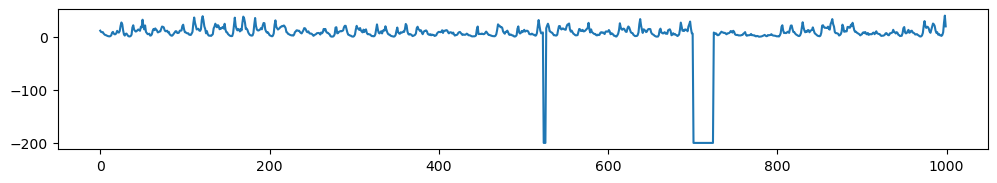

In [233]:
#%% load dataset 
filename= r'AirQualityUCI.xlsx'
df= pd.read_excel(filename)

# print(df.tail(5))
names= df.columns
target= df.iloc[:,5].to_numpy()
df= df.drop(names[5], axis=1)
data= df.iloc[:,2:].to_numpy()

data[np.isnan(data)]=0
target[np.isnan(target)]=0

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(target[:1000])
plt.show()

In [234]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=False)

In [235]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [236]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain).type(torch.float32)
y_train= torch.from_numpy(y_train).type(torch.float32)

Xtest= torch.from_numpy(Xtest).type(torch.float32)
y_test= torch.from_numpy(y_test).type(torch.float32)

In [237]:
class MLP_Regressor(nn.Module):
    def __init__(self,
                 input_size=64,
                 hidden_size1=128, 
                 hidden_size2=128, 
                 hidden_size3=128, 
                 num_classes=10):
        
        super(MLP_Regressor, self).__init__()
        

        self.fc1= nn.Linear(in_features=input_size,
                            out_features=hidden_size1)
        
        self.fc2= nn.Linear(in_features=hidden_size1,
                            out_features=hidden_size2)
        
        self.fc3= nn.Linear(in_features=hidden_size2,
                            out_features=hidden_size3)
                
        self.fc4= nn.Linear(in_features=hidden_size3,
                            out_features=num_classes)
        self.fun= nn.Tanh()
        
    def forward(self, x):
        
        out= self.fc1(x)
        out= self.fun(out)
        
        out= self.fc2(out)
        out= self.fun(out)
        
        out= self.fc3(out)
        out= self.fun(out)
                
        out= self.fc4(out)
        return out

In [238]:
#% build data loader 
ds= TensorDataset(Xtrain,y_train)
train_loader= DataLoader(ds,batch_size=32,
                         shuffle=True,
                         drop_last=True)

#% build data loader 
ds_test= TensorDataset(Xtest,y_test)
test_loader= DataLoader(ds_test,batch_size=32,
                         shuffle=False,
                         drop_last=True)

In [239]:
#%% train Neural Network
torch.manual_seed(1)
num_features=Xtrain.shape[1]
model= MLP_Regressor(input_size=num_features, 
                     hidden_size1=64, 
                     hidden_size2=32, 
                     hidden_size3=16, 
                     num_classes=1)

criterion= nn.MSELoss()
optimizer= optim.Adam(model.parameters(),lr=0.01)

In [240]:
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [1/30], Loss: 868.7921
Epoch [2/30], Loss: 661.3966
Epoch [3/30], Loss: 518.3169
Epoch [4/30], Loss: 407.2092
Epoch [5/30], Loss: 303.4435
Epoch [6/30], Loss: 228.9412
Epoch [7/30], Loss: 171.6469
Epoch [8/30], Loss: 118.1483
Epoch [9/30], Loss: 80.2375
Epoch [10/30], Loss: 52.5568
Epoch [11/30], Loss: 33.1163
Epoch [12/30], Loss: 19.9251
Epoch [13/30], Loss: 12.9689
Epoch [14/30], Loss: 7.0829
Epoch [15/30], Loss: 4.0157
Epoch [16/30], Loss: 2.0628
Epoch [17/30], Loss: 1.0833
Epoch [18/30], Loss: 0.7216
Epoch [19/30], Loss: 0.5546
Epoch [20/30], Loss: 2.0214
Epoch [21/30], Loss: 0.4872
Epoch [22/30], Loss: 1.1022
Epoch [23/30], Loss: 0.3002
Epoch [24/30], Loss: 0.2225
Epoch [25/30], Loss: 0.2149
Epoch [26/30], Loss: 0.1904
Epoch [27/30], Loss: 0.8429
Epoch [28/30], Loss: 0.2207
Epoch [29/30], Loss: 0.1764
Epoch [30/30], Loss: 0.1724


In [241]:
with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    ypred_list = []
    ytrue_list = []
    
    for inputs, labels in test_loader:
        predicted= model(inputs)

        ypred_list.extend(predicted.numpy())
        ytrue_list.extend(labels.numpy())



ypred= np.array(ypred_list).ravel()
d_test= np.array(ytrue_list).ravel()

In [242]:
print(ypred.shape,d_test.shape)

(2784,) (2784,)


MSE:0.418
MAE:0.590
R square:1.000


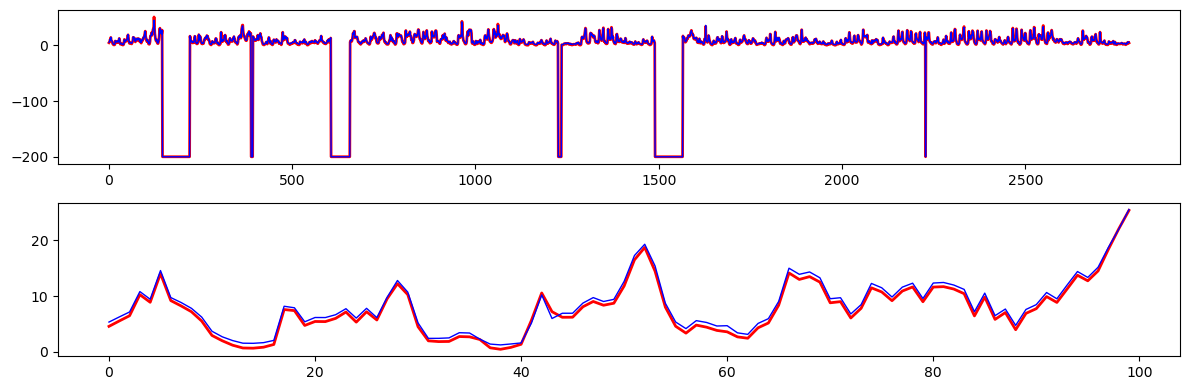

In [243]:
#%% validate your Neural Network
MSE= metrics.mean_squared_error(d_test,ypred)
MAE= metrics.mean_absolute_error(d_test,ypred)
r2= metrics.r2_score(d_test,ypred)

print(f'MSE:{MSE:.3f}')
print(f'MAE:{MAE:.3f}')
print(f'R square:{r2:.3f}')

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(d_test,'r',linewidth=2)
plt.plot(ypred,'b',linewidth=1)
plt.subplot(2,1,2)
plt.plot(d_test[:100],'r',linewidth=2)
plt.plot(ypred[:100],'b',linewidth=1)
plt.tight_layout()
plt.show()4